# Exploratory Data Analysis on Global Superstore Sales Dataset

In [ ]:
pip install plotly

In [ ]:
# importing the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import os
import warnings
warnings.filterwarnings('ignore')

pio.renderers.default = 'browser'

In [ ]:
# loading the dataset
file_path = 'Sample_superstore.csv'
df = pd.read_csv(file_path, parse_dates=['Order Date'], encoding='latin1')

In [ ]:
# checking the first few rows
df.head()

   Row ID         Order ID Order Date  Ship Date       Ship Mode  \
0       1  CA-2016-152156 2016-11-08  11/11/2016    Second Class   
1       2  CA-2016-152156 2016-11-08  11/11/2016    Second Class   
2       3  CA-2016-138688 2016-06-12  06/16/2016    Second Class   
3       4  US-2015-108966 2015-10-11  10/18/2015  Standard Class   
4       5  US-2015-108966 2015-10-11  10/18/2015  Standard Class   


In [ ]:
# handling missing values and removing duplicates
df['Profit'].fillna(df['Profit'].mean(), inplace=True)
df['Sales'].fillna(df['Sales'].mean(), inplace=True)
df.dropna(subset=['Region', 'Category'], inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
# checking data types and basic dataset info
print('Data Types:\n', df.dtypes)
print('\nDataset Info:')
print(df.info())

Data Types:
 Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Row ID         9994 non-null   int64
 1   Order ID       9994 non-null   object
 2   Order

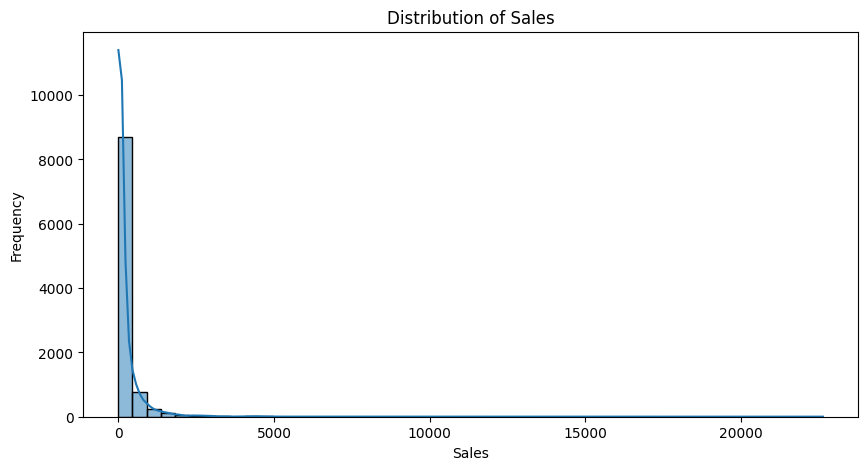

In [ ]:
# distribution of sales to understand how sales values are spread
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

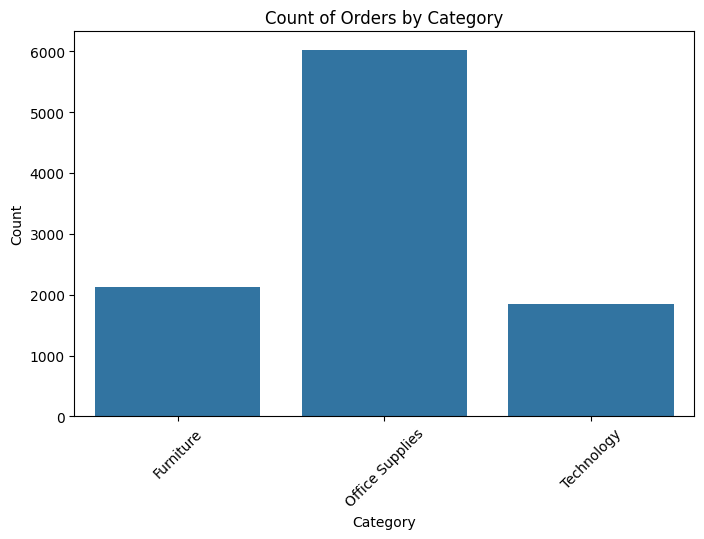

In [ ]:
# count of orders in each product category
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Category')
plt.title('Count of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

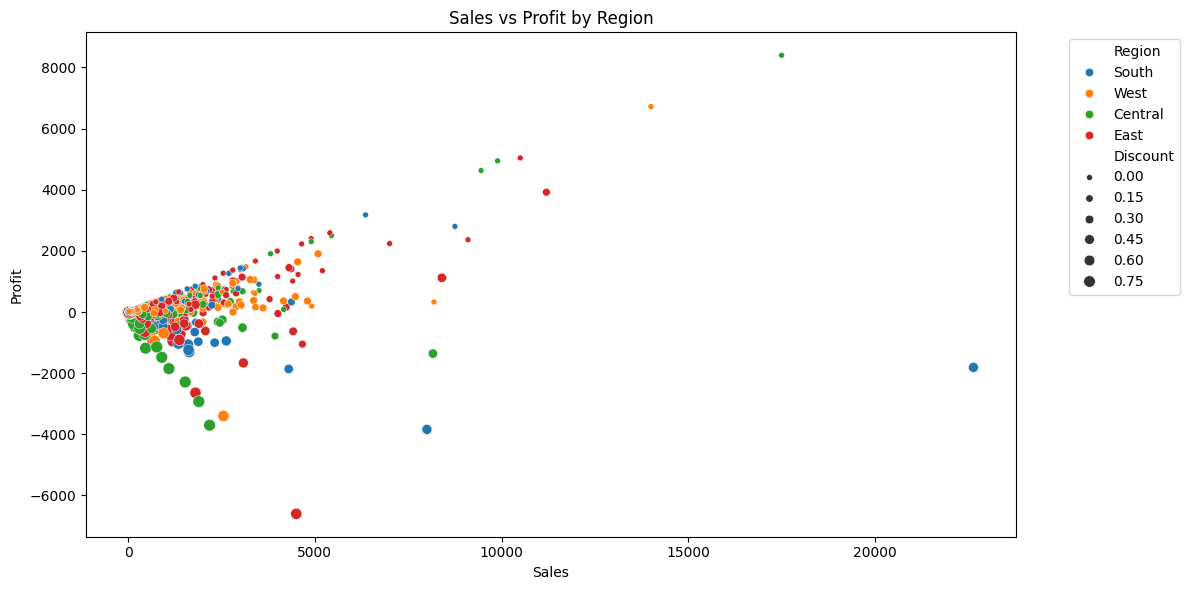

In [ ]:
# sales vs profit across regions to see which regions are more profitable
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Region', size='Discount')
plt.title('Sales vs Profit by Region')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

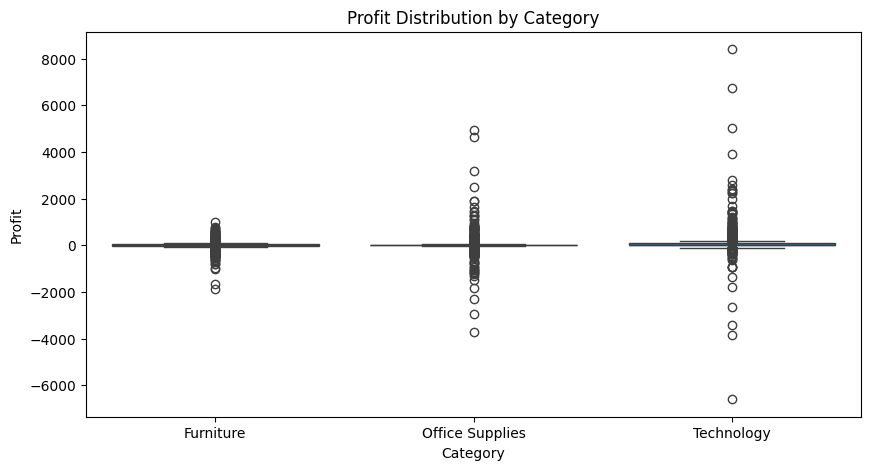

In [ ]:
# profit distribution across categories using a boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

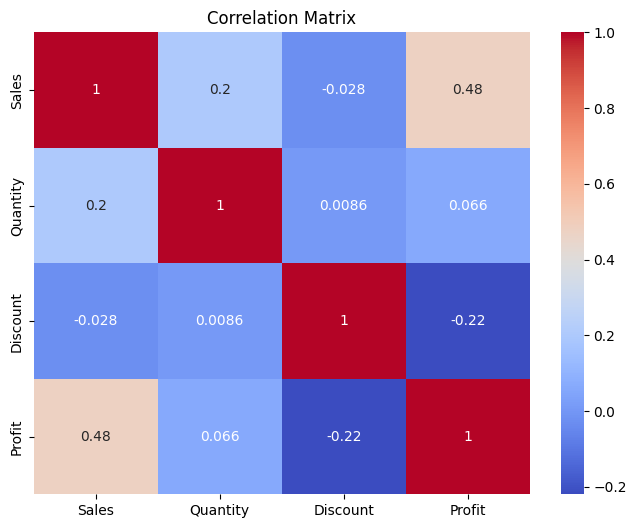

In [ ]:
# correlation matrix to see how numeric variables relate to each other
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# monthly sales trend over time using an interactive plotly chart
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()
monthly_sales['Order Month'] = monthly_sales['Order Month'].astype(str)

fig = px.line(monthly_sales, x='Order Month', y='Sales', title='Monthly Sales Trend')
fig.update_xaxes(tickangle=45)
fig.show()

In [ ]:
# key findings from the analysis
print('- Q4 Sales Peaks: Sales consistently peak in Q4 (e.g., Dec 2014: ~80k, Dec 2017: ~110k), driven by holiday seasons.')
print('- Mid-Year Dips: Sales drop significantly in June-July each year (often below 30k).')
print('- Overall Growth Trend: Steady upward trend in sales from 2014 to 2017 despite monthly volatility.')
print('- Regional Contributions: The West region leads in total sales followed by the East region.')
print('- Discount Impact: Higher discounts often lead to negative profit, visible in the scatter plot.')
print('- Top Category: Office Supplies has the highest order count but Technology generates the most revenue.')

- Q4 Sales Peaks: Sales consistently peak in Q4 (e.g., Dec 2014: ~80k, Dec 2017: ~110k), driven by holiday seasons.
- Mid-Year Dips: Sales drop significantly in June-July each year (often below 30k).
- Overall Growth Trend: Steady upward trend in sales from 2014 to 2017 despite monthly volatility.
- Regional Contributions: The West region leads in total sales followed by the East region.
- Discount Impact: Higher discounts often lead to negative profit, visible in the scatter plot.
- Top Category: Office Supplies has the highest order count but Technology generates the most revenue.


In [ ]:
# saving the cleaned dataset
df.to_csv('cleaned_superstore_data.csv', index=False)
print('Cleaned dataset saved as cleaned_superstore_data.csv')

Cleaned dataset saved as cleaned_superstore_data.csv
